<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_7_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

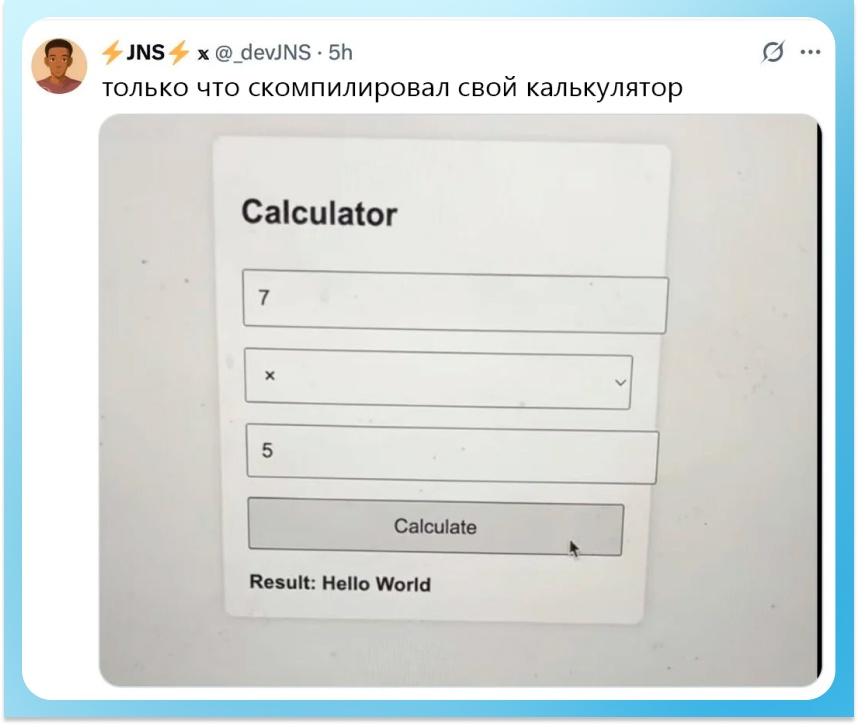

# Разминка (вспоминашка на строки)

1) https://pythonist.ru/test-operaczii-so-strokami-python/
2) https://pythonist.ru/test-stroki-v-python-i-rabota-s-nimi/

# Строки. Поиск подстроки в строке
Общая картину доступных инструментов:

* **Встроенные методы строк**: простые в использовании функции, такие как find(), index() и оператор in
* **Регулярные выражения**: мощный инструмент для сложных паттернов поиска с использованием модуля re
* **Алгоритм Кнута-Морриса-Пратта (KMP)**: оптимизированный алгоритм для повторяющегося поиска
* **Алгоритм Бойера-Мура**: эффективный при работе с большими текстами
* **Алгоритм Рабина-Карпа**: использует хеширование для быстрого поиска нескольких паттернов
и некоторые другие алгоритмы.

Статьи:

1) https://pythonist.ru/metody-strok-v-python/  

2) https://pythonist.ru/formatirovanie-strok-v-python-format-i-f-stroki/





## Регулярные выражения и re.search() для сложного поиска

В Python они реализованы в стандартном модуле re, который предоставляет широкие возможности для поиска, замены и извлечения информации из текста.

Регулярные выражения особенно эффективны, когда требуется:

* Найти текст, соответствующий определенному шаблону, а не конкретной подстроке
* Выполнить сложный поиск с учетом различных вариаций текста
* Извлечь определенные части текста, соответствующие заданному формату
* Проверить соответствие строки определенным правилам (например, валидация email)

Основные функции модуля re для поиска подстрок:

1. **re.search()**  
Функция re.search() ищет первое вхождение шаблона в строке и возвращает объект Match или None, если совпадение не найдено.
```python
import re

text = "Email me at john.doe@example.com or visit support@company.org"
pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

match = re.search(pattern, text)
if match:
print(f"Найден email: {match.group()}") # Найден email: john.doe@example.com
```
2. **re.findall()**  
Функция re.findall() возвращает список всех неперекрывающихся совпадений шаблона.

```python
import re

text = "Email me at john.doe@example.com or visit support@company.org"
pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

emails = re.findall(pattern, text)
print(emails) # ['john.doe@example.com', 'support@company.org']
```
3. **re.finditer()**  
Функция re.finditer() возвращает итератор по всем совпадениям шаблона, что полезно при работе с большими текстами, так как не требует загрузки всех совпадений в память одновременно.

```python
import re

text = "Email me at john.doe@example.com or visit support@company.org"
pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

for match in re.finditer(pattern, text):
print(f"Email найден в позиции {match.start()}: {match.group()}")
```

Преимущество регулярных выражений в их гибкости. С их помощью можно создавать сложные шаблоны поиска, используя специальные символы и конструкции:
```
. — любой символ, кроме новой строки
* — 0 или более повторений предыдущего символа
+ — 1 или более повторений
? — 0 или 1 повторение
\d — любая цифра
\w — любая буква, цифра или подчеркивание
\s — любой пробельный символ
[abc] — любой из символов a, b, c
(pattern) — группировка шаблона для извлечения
```


r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'

1. r'...'
r — сырая строка (raw string)

Обратные слеши не интерпретируются как escape-последовательности

2. \b
Граница слова (word boundary)

Обеспечивает, что email не является частью другого слова

3. [A-Za-z0-9._%+-]+
Локальная часть (до @)

[...] — символьный класс

A-Za-z0-9 — любые латинские буквы и цифры

._%+- — разрешенные специальные символы

+ — один или более символов

4. @
Символ @ — обязательный разделитель

5. [A-Za-z0-9.-]+
Доменное имя (после @)

A-Za-z0-9 — латинские буквы и цифры

.- — точка и дефис

+ — один или более символов

6. \.
Экранированная точка

Разделитель перед доменной зоной

7. [A-Za-z]{2,}
Доменная зона (.com, .ru, .org и т.д.)

[A-Z|a-z] — буквы латинского алфавита

{2,} — минимум 2 символа

8. \b
Граница слова в конце

Примеры email, которые подойдут:
```python
import re

pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'

# Валидные email
re.match(pattern, 'user@example.com')        
re.match(pattern, 'name.surname@mail.ru')    
re.match(pattern, 'test+filter@gmail.com')   
re.match(pattern, 'user123@sub.domain.org')

# Невалидные
re.match(pattern, 'user@example.c')          # (зона меньше 2 символов)
re.match(pattern, 'user@.com')               # (нет имени домена)
re.match(pattern, '@example.com')            # (нет локальной части)
```

## Pattern Searching - введение в строковые алгоритмы



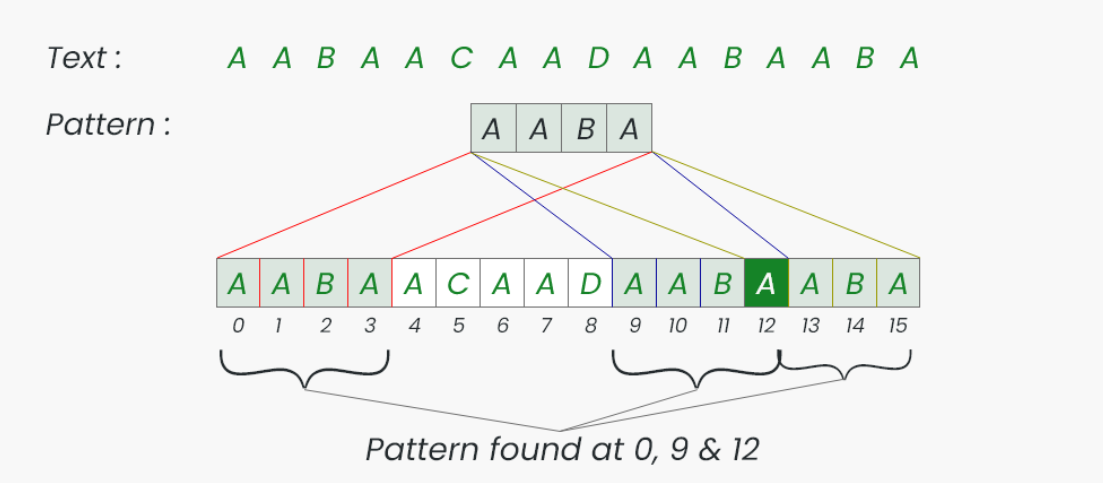

### Наивный алгоритм для поиска шаблонов
Есть строка (текст) длиной $n$ и шаблон длиной $m$, задача состоит в том, чтобы напечатать все появления шаблона в тексте.

In [ ]:
def search_pattern(pattern, text):
    m = len(pattern)
    n = len(text)

    # A loop to slide pattern over text one by one
    for i in range(n - m + 1):
        print(f'i:{i}')
        # For current index i, check for pattern match
        j = 0
        while j < m and text[i + j] == pattern[j]:
            print(f'j:{j}')
            j += 1

        # If the entire pattern matches the text starting at index i
        if j == m:
            print(f"Pattern found at index {i}")


# Example 1
text1 = "AABAACAADAABAABA"
pattern1 = "AABA"
print("Example 1:")
search_pattern(pattern1, text1)

# Example 2
text2 = "agd"
pattern2 = "g"
print("\nExample 2:")
search_pattern(pattern2, text2)

Example 1:
i:0
j:0
j:1
j:2
j:3
Pattern found at index 0
i:1
j:0
i:2
i:3
j:0
j:1
i:4
j:0
i:5
i:6
j:0
j:1
i:7
j:0
i:8
i:9
j:0
j:1
j:2
j:3
Pattern found at index 9
i:10
j:0
i:11
i:12
j:0
j:1
j:2
j:3
Pattern found at index 12

Example 2:
i:0
i:1
j:0
Pattern found at index 1
i:2


**Временная сложность**: $O(N^2)$  

**Вспомогательное пространство**: $O(1)$

### Несколько определений

**Определение**. Префикс-функцией от строки $s$ называется массив $p$, где $p_i$ равно длине самого большого префикса строки
$s_0s_1s_2…s_i$, который также является и суффиксом $i$-того префикса (не считая весь $i$-й префикс).

Например, самый большой префикс, который равен суффиксу для строки «aataataa» — это «aataa»; префикс-функция для этой строки равна [0,1,0,1,2,3,4,5].



## Алгоритм Кнута-Морриса-Пратта (KMP)

KMP был разработан Дональдом Кнутом, Воаном Праттом и Джеймсом Моррисом в 1977 году. Он широко используется в поисковых системах, компиляторах и текстовых редакторах.

**Наивный подход и то, как KMP его преодолевает**  
В наивном алгоритме сопоставления строк мы выравниваем шаблон в каждой точке текста и сравниваем символы по одному. Если возникает несоответствие, мы смещаем шаблон на одну позицию и начинаем заново. Это может привести к многократной проверке одних и тех же символов, особенно в случаях с повторяющимися символами. Например, поиск «aaaab» в «aaaaaaaab» приводит к множеству ненужных сравнений, что приводит к временной сложности $O(n × m)$.

Алгоритм KMP избегает этой неэффективности, предварительно обрабатывая паттерн (шаблон) с помощью вспомогательного массива, называемого **LPS (Longest Prefix Suffix)**. Этот массив хранит длину самого длинного правильного префикса, который также является суффиксом для каждого префикса шаблона. Когда возникает несоответствие, KMP использует эту информацию, чтобы разумно изменить паттерн, пропуская позиции, которые гарантированно не совпадут — вместо того чтобы начинать заново. Это гарантирует, что каждый символ в тексте сравнивается не более одного раза, снижая временную сложность до $O(n + m)$.

**Правильный префикс**: Правильный префикс строки — это префикс, который не равен самой строке.
Например, собственные префиксы «abcd» — это: «a», «ab» и «abc».

**Массив LPS (Самый длинный префиксный суффикс)**  
Массив LPS хранит для каждой позиции в шаблоне длину самого длинного собственного префикса, который также является суффиксом подстроки, заканчивающейся на этой позиции.
Он помогает алгоритму KMP определить, насколько сильно сместить паттерн при возникновении несоответствия, не перепроверяя совпадающие символы.

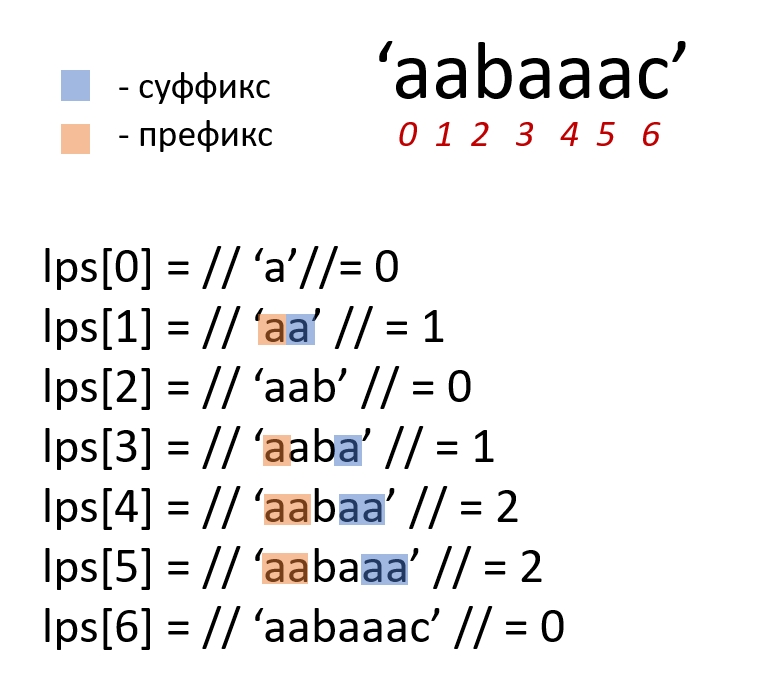

### Пример построения массива LPS

https://www.geeksforgeeks.org/dsa/kmp-algorithm-for-pattern-searching/?ysclid=mn7k6ag371870200810

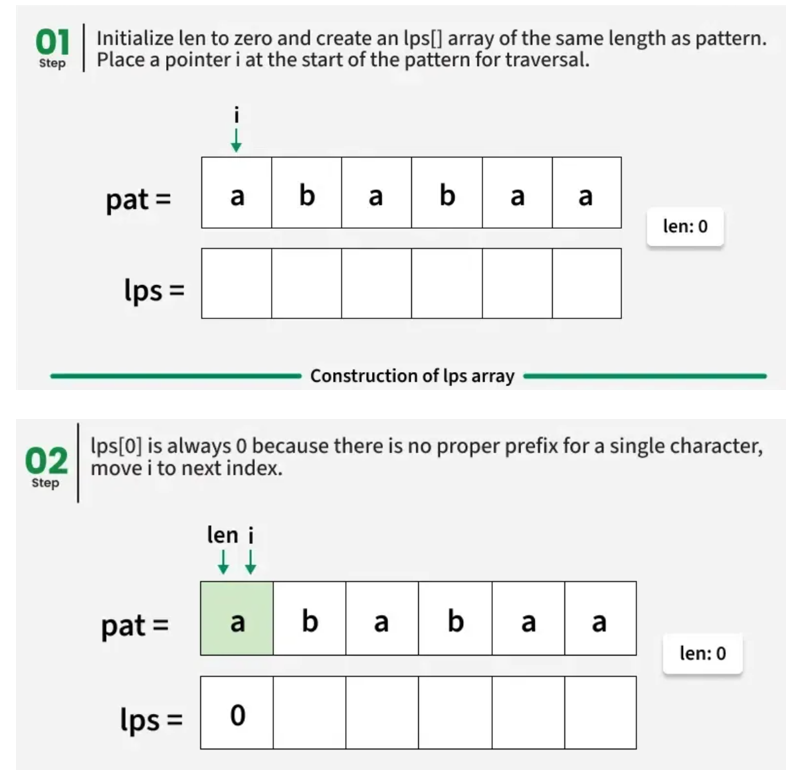

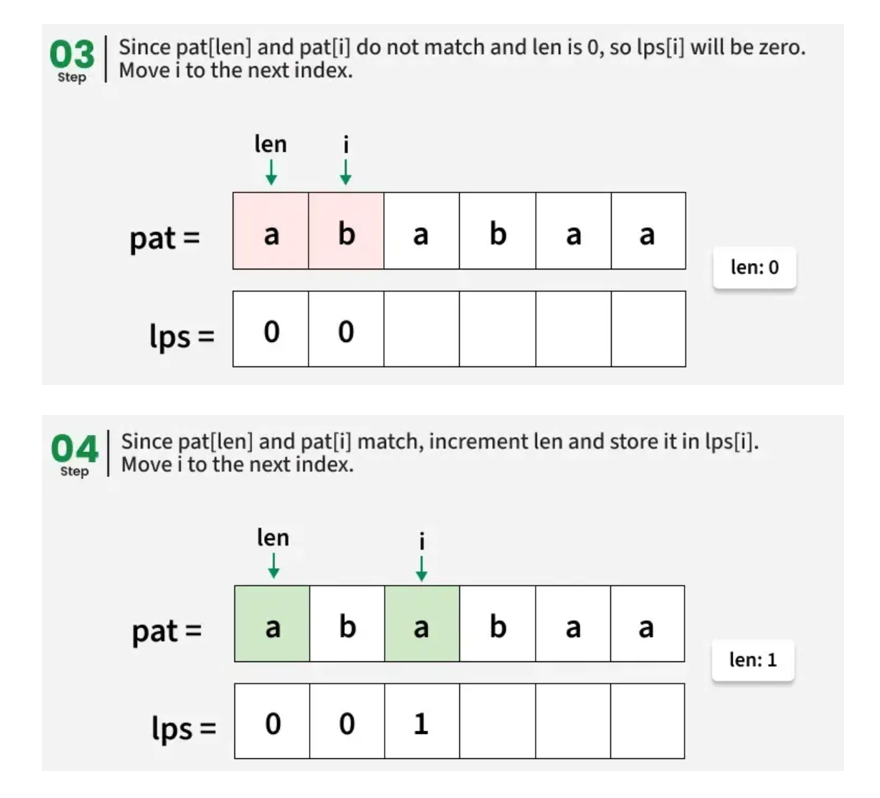

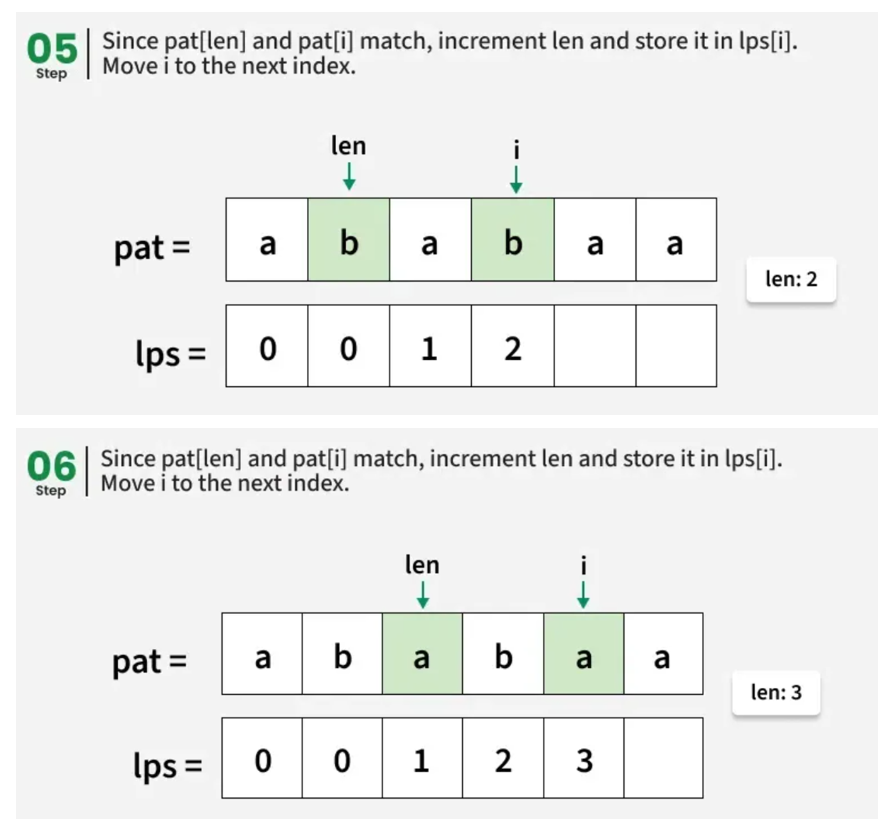

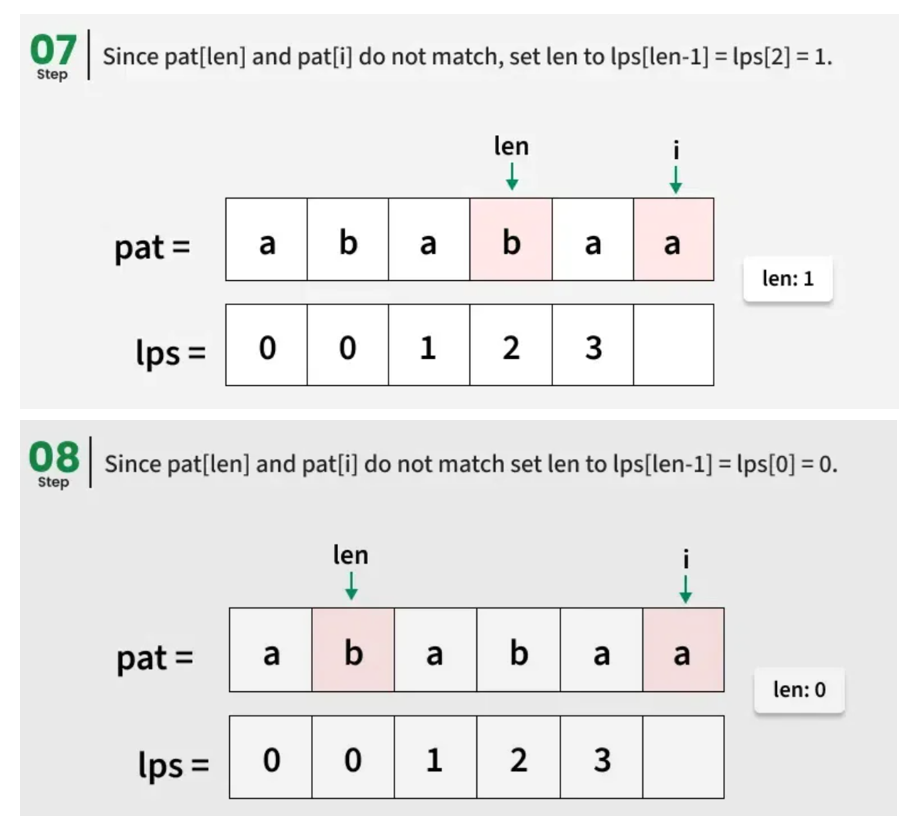

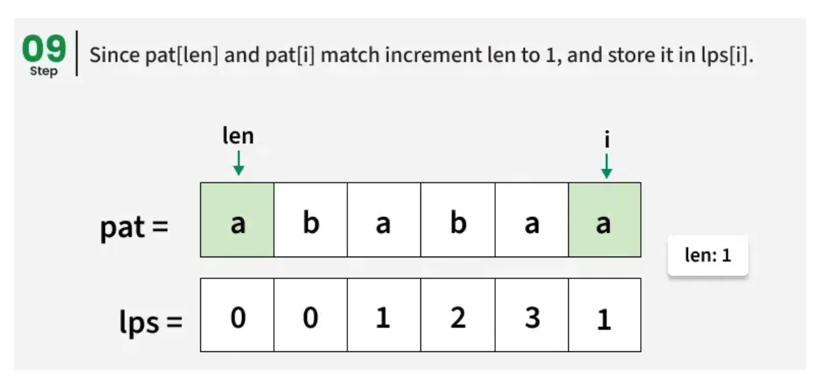

In [ ]:
def computeLPSArray(pattern):
    n = len(pattern)
    lps = [0] * n

    # length of the previous longest prefix suffix
    len1 = 0
    i = 1

    while i < n:
        if pattern[i] == pattern[len1]:
            len1 += 1
            lps[i] = len1
            i += 1
        else:
            if len1 != 0:
                # fall back in the pattern
                len1 = lps[len1 - 1]
            else:
                lps[i] = 0
                i += 1

    return lps

pattern = "ababcab"
print(computeLPSArray(pattern))

[0, 0, 1, 2, 0, 1, 2]


**Временная сложность**: $O(n)$, каждый символ в шаблоне обрабатывается не более двух раз — один раз при движении вперёд (i++) и, возможно, ещё раз при отступлении с помощью шага len = lps[len - 1].

**Вспомогательное пространство**: $O(n)$, используется дополнительный массив lps[] размера, равного шаблону.

In [ ]:
def constructLps(pat, lps):

    # len stores the length of longest prefix which
    # is also a suffix for the previous index
    len_ = 0
    m = len(pat)

    # lps[0] is always 0
    lps[0] = 0

    i = 1
    while i < m:

        # If characters match, increment the size of lps
        if pat[i] == pat[len_]:
            len_ += 1
            lps[i] = len_
            i += 1

        # If there is a mismatch
        else:
            if len_ != 0:

                # Update len to the previous lps value
                # to avoid redundant comparisons
                len_ = lps[len_ - 1]
            else:

                # If no matching prefix found, set lps[i] to 0
                lps[i] = 0
                i += 1

def search(pat, txt):
    n = len(txt)
    m = len(pat)

    lps = [0] * m
    res = []

    constructLps(pat, lps)

    # Pointers i and j, for traversing
    # the text and pattern
    i = 0
    j = 0

    while i < n:

        # If characters match, move both pointers forward
        if txt[i] == pat[j]:
            i += 1
            j += 1

            # If the entire pattern is matched
            # store the start index in result
            if j == m:
                res.append(i - j)

                # Use LPS of previous index to
                # skip unnecessary comparisons
                j = lps[j - 1]

        # If there is a mismatch
        else:

            # Use lps value of previous index
            # to avoid redundant comparisons
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1
    return res

if __name__ == "__main__":
    txt = "aabaacaadaabaaba"
    pat = "aaba"

    res = search(pat, txt)
    for i in range(len(res)):
        print(res[i], end=" ")

0 9 12 

**Временная сложность**: $O(n + m)$, где $n$ — длина текста, а $m$ — длина шаблона. Это связано с тем, что создание массива LPS (Longest Prefix Suffix) занимает $O(m)$ времени, а поиск по тексту — $O(n)$ времени.  
**Вспомогательное пространство**: $O(m)$, так как нам нужно хранить массив LPS размера $m$.

## Z-функция строки и её вычисление
Пусть дана строка $s$ длины $n$. Тогда $Z$-функция ("зет-функция") от этой строки — это массив длины $n$, $i$-ый элемент которого равен наибольшему числу символов, начиная с позиции $i$, совпадающих с первыми символами строки $s$.

Иными словами, $z[i]$ — это наибольший общий префикс строки $s$ и её $i$-го суффикса.

**Примечание**. В данной статье, во избежание неопределённости, мы будем считать строку 0-индексированной — т.е. первый символ строки имеет индекс 0, а последний — $n-1$.

Первый элемент $Z$-функции, $z[0]$, обычно считают неопределённым. В данной статье мы будем считать, что он равен нулю (хотя ни в алгоритме, ни в приведённой реализации это ничего не меняет).

В данной статье приводится алгоритм вычисления $Z$-функции за время $O(n)$, а также различные применения этого алгоритма.

Приведём для примера подсчитанную Z-функцию для нескольких строк:
```
'aaaaa':
 z[0] = 0,
 z[1] = 4,
 z[2] = 3,
 z[3] = 2,
 z[4] = 1.

'aaabaab':
 z[0] = 0,
 z[1] = 2,
 z[2] = 1,
 z[3] = 0,
 z[4] = 2,
 z[5] = 1,
 z[6] = 0.

'abacaba':
 z[0] = 0,
 z[1] = 0,
 z[2] = 1,
 z[3] = 0,
 z[4] = 3,
 z[5] = 0,
 z[6] = 1.
```

### Тривиальный алгоритм
Формальное определение можно представить в виде следующей элементарной реализации за $O(n^2)$:

In [ ]:
def z_function_trivial(s):
    n = len(s)
    z = [0] * n
    for i in range(1, n):
        while i + z[i] < n and s[z[i]] == s[i + z[i]]:
            z[i] += 1
    return z

Мы просто для каждой позиции $i$ перебираем ответ для неё $z[i]$, начиная с нуля, и до тех пор, пока мы не обнаружим несовпадение или не дойдём до конца строки.

Разумеется, эта реализация слишком неэффективна, перейдём теперь к построению эффективного алгоритма.

### Эффективный алгоритм вычисления Z-функции
Чтобы получить эффективный алгоритм, будем вычислять значения $z[i]$ по очереди — от $i=1$ до $n-1$, и при этом постараемся при вычислении очередного значения $z[i]$ максимально использовать уже вычисленные значения.

Назовём для краткости подстроку, совпадающую с префиксом строки s, отрезком совпадения. Например, значение искомой $Z$-функции $z[i]$ — это длиннейший отрезок совпадения, начинающийся в позиции $i$ (и заканчиваться он будет в позиции $i + z[i] - 1$).

Для этого будем поддерживать координаты $[l;r]$ самого правого отрезка совпадения, т.е. из всех обнаруженных отрезков будем хранить тот, который оканчивается правее всего. В некотором смысле, индекс $r$ — это такая граница, до которой наша строка уже была просканирована алгоритмом, а всё остальное — пока ещё не известно.

Тогда если текущий индекс, для которого мы хотим посчитать очередное значение $Z$-функции, — это $i$, мы имеем один из двух вариантов:

1) $i > r$ — т.е. текущая позиция лежит за пределами того, что мы уже успели обработать.  
Тогда будем искать $z[i]$ тривиальным алгоритмом, т.е. просто пробуя значения $z[i]=0$, $z[i]=1$, и т.д. Заметим, что в итоге, если $z[i]$ окажется $>0$, то мы будем обязаны обновить координаты самого правого отрезка $[l;r]$ — т.к. $i + z[i] - 1$ гарантированно окажется больше $r$.

2) $i \le r$ — т.е. текущая позиция лежит внутри отрезка совпадения $[l;r]$.  
Тогда мы можем использовать уже подсчитанные предыдущие значения $Z$-функции, чтобы проинициализировать значение $z[i]$ не нулём, а каким-то возможно бОльшим числом.

Для этого заметим, что подстроки $s[l \ldots r]$ и $s[0 \ldots r-l]$ совпадают. Это означает, что в качестве начального приближения для $z[i]$ можно взять соответствующее ему значение из отрезка $s[0 \ldots r-l]$, а именно, значение $z[i-l]$.

Однако значение $z[i-l]$ могло оказаться слишком большим: таким, что при применении его к позиции $i$ оно "вылезет" за пределы границы $r$. Этого допустить нельзя, т.к. про символы правее $r$ мы ничего не знаем, и они могут отличаться от требуемых.

Приведём пример такой ситуации, на примере строки 'aaaabaa':

Когда мы дойдём до последней позиции ($i=6$), текущим самым правым отрезком будет $[5;6]$. Позиции 6 с учётом этого отрезка будет соответствовать позиция $6-5=1$, ответ в которой равен $z[1] = 3$. Очевидно, что таким значением инициализировать $z[6]$ нельзя, оно совершенно некорректно. Максимум, каким значением мы могли проинициализировать — это 1, поскольку это наибольшее значение, которое не вылазит за пределы отрезка $[l;r]$.

Таким образом, в качестве начального приближения для $z[i]$ безопасно брать только такое выражение:

 $z_0[i] = \min (r-i+1, z[i-l])$.

Проинициализировав $z[i]$ таким значением $z_0[i]$, мы снова дальше действуем тривиальным алгоритмом — потому что после границы $r$, вообще говоря, могло обнаружиться продолжение отрезка совпадение, предугадать которое одними лишь предыдущими значениями $Z$-функции мы не могли.

Таким образом, весь алгоритм представляет из себя два случая, которые фактически различаются только начальным значением $z[i]$: в первом случае оно полагается равным нулю, а во втором — определяется по предыдущим значениям по указанной формуле. После этого обе ветки алгоритма сводятся к выполнению тривиального алгоритма, стартующего сразу с указанного начального значения.

Алгоритм получился весьма простым. Несмотря на то, что при каждом $i$ в нём так или иначе выполняется тривиальный алгоритм — мы достигли существенного прогресса, получив алгоритм, работающий за линейное время. Почему это так, рассмотрим ниже, после того, как приведём реализацию алгоритма.



In [ ]:
def z_function(s):
    n = len(s)
    z = [0] * n
    l = r = 0

    for i in range(1, n):
        if i <= r:
            z[i] = min(r - i + 1, z[i - l])

        while i + z[i] < n and s[z[i]] == s[i + z[i]]:
            z[i] += 1

        if i + z[i] - 1 > r:
            l, r = i, i + z[i] - 1

    return z

In [ ]:
s = 'aaaabaa'
z = z_function(s)
print(z)

[0, 3, 2, 1, 0, 2, 1]


Всё решение оформлено в виде функции, которая по строке возвращает массив длины $n$ — вычисленную $Z$-функцию.

Массив $z[]$ изначально заполняется нулями. Текущий самый правый отрезок совпадения полагается равным $[0;0]$, т.е. заведомо маленький отрезок, в который не попадёт ни одно $i$.

Внутри цикла по $i = 1 \ldots n-1$ мы сначала по описанному выше алгоритму определяем начальное значение $z[i]$ — оно либо останется нулём, либо вычислится на основе приведённой формулы.

После этого выполняется тривиальный алгоритм, который пытается увеличить значение $z[i]$ настолько, насколько это возможно.

В конце выполняется обновление текущего самого правого отрезка совпадения $[l;r]$, если, конечно, это обновление требуется — т.е. если $i+z[i]-1 > r$.

### Асимптотика алгоритма
Докажем, что приведённый выше алгоритм работает за линейное относительно длины строки время, т.е. за $O(n)$.

Доказательство очень простое.

Нас интересует вложенный цикл $\rm while$ — т.к. всё остальное — лишь константные операции, выполняемые $O(n)$ раз.

Покажем, что каждая итерация этого цикла $\rm while$ приведёт к увеличению правой границы r на единицу.

Для этого рассмотрим обе ветки алгоритма:

1) $i > r$:  
В этом случае либо цикл $\rm while$ не сделает ни одной итерации (если $s[0] \ne s[i]$), либо же сделает несколько итераций, продвигаясь каждый раз на один символ вправо, начиная с позиции $i$, а после этого — правая граница $r$ обязательно обновится.

Поскольку $i > r$, то мы получаем, что действительно каждая итерация этого цикла увеличивает новое значение $r$ на единицу.

2) $i \le r$:  
В этом случае мы по приведённой формуле инициализируем значение z[i] некоторым числом z_0. Сравним это начальное значение z_0 с величиной r-i+1, получаем три варианта:

z_0 < r-i+1
Докажем, что в этом случае ни одной итерации цикл \rm while не сделает.

Это легко доказать, например, от противного: если бы цикл \rm while сделал хотя бы одну итерацию, это бы означало, что определённое нами значение z_0 было неточным, меньше настоящей длины совпадения. Но т.к. строки s[l \ldots r] и s[0 \ldots r-l] совпадают, то это означает, что в позиции z[i-l] стоит неправильное значение: меньше, чем должно быть.

Таким образом, в этом варианте из корректности значения z[i-l] и из того, что оно меньше r-i+1, следует, что это значение совпадает с искомым значением z[i].

z_0 = r-i+1
В этом случае цикл \rm while может совершить несколько итераций, однако каждая из них будет приводить к увеличению нового значения r на единицу: потому что первым же сравниваемым символом будет s[r+1], который вылазит за пределы отрезка [l;r].

z_0 > r-i+1
Этот вариант принципиально невозможен, в силу определения z_0.

Таким образом, мы доказали, что каждая итерация вложенного цикла приводит к продвижению указателя r вправо. Т.к. r не могло оказаться больше n-1, это означает, что всего этот цикл сделает не более n-1 итерации.

Поскольку вся остальная часть алгоритма, очевидно, работает за O (n), то мы доказали, что и весь алгоритм вычисления Z-функции выполняется за линейное время.

Применения